# Bayesian Multinomial Logit with Pyro

In [1]:
import pandas as pd
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import seaborn as sns


# Set seeds for reproducibility
np.random.seed(11)
torch.manual_seed(11)
pyro.set_rng_seed(11)

In [2]:
df = pd.read_csv('swissmetro.dat', sep='\t')
df.to_csv('swissmetro.csv', index=False)

### Load and explore data

In [3]:
df = pd.read_csv('swissmetro.dat', sep='\t')
print(df.head())
print(df.shape)

# Filter: exclude unknown choices and non-commute/business trips
df = df[(df['CHOICE'] != 0) & ((df['PURPOSE'] == 1) | (df['PURPOSE'] == 3))]

print(f"After filtering: {df.shape[0]} rows")

# Select a random subset of 50 IDs
selected_ids = df['ID'].drop_duplicates().sample(n=50)

# Filter the dataset to include only rows with the selected IDs
df = df[df['ID'].isin(selected_ids)]

print(f"With 50 IDs: {df.shape[0]} rows")
print(f"Columns: {df.columns.tolist()}")


   GROUP  SURVEY  SP  ID  PURPOSE  FIRST  TICKET  WHO  LUGGAGE  AGE  ...  \
0      2       0   1   1        1      0       1    1        0    3  ...   
1      2       0   1   1        1      0       1    1        0    3  ...   
2      2       0   1   1        1      0       1    1        0    3  ...   
3      2       0   1   1        1      0       1    1        0    3  ...   
4      2       0   1   1        1      0       1    1        0    3  ...   

   TRAIN_TT  TRAIN_CO  TRAIN_HE  SM_TT  SM_CO  SM_HE  SM_SEATS  CAR_TT  \
0       112        48       120     63     52     20         0     117   
1       103        48        30     60     49     10         0     117   
2       130        48        60     67     58     30         0     117   
3       103        40        30     63     52     20         0      72   
4       130        36        60     63     42     20         0      90   

   CAR_CO  CHOICE  
0      65       2  
1      84       2  
2      52       2  
3      52       2 

In [4]:
# Check available modes and choice distribution
print(f"Unique choices: {sorted(df['CHOICE'].unique())}")
print(f"\nChoice distribution:\n{df['CHOICE'].value_counts().sort_index()}")
print(f"\nMode availability:")
print(f"TRAIN_AV: {df['TRAIN_AV'].sum()} / {len(df)}")
print(f"SM_AV: {df['SM_AV'].sum()} / {len(df)}")
print(f"CAR_AV: {df['CAR_AV'].sum()} / {len(df)}")

Unique choices: [np.int64(1), np.int64(2), np.int64(3)]

Choice distribution:
CHOICE
1     77
2    247
3    126
Name: count, dtype: int64

Mode availability:
TRAIN_AV: 450 / 450
SM_AV: 450 / 450
CAR_AV: 369 / 450


### Prepare data for choice model

Transform to long format (one row per alternative per decision) for the discrete choice model.

In [5]:
# We'll work with travel time and cost
# Modes: 1=Train, 2=SwissMetro, 3=Car

# Standardize attributes (z-score: (x - mean) / std)
df['TRAIN_TT_SCALED'] = (df['TRAIN_TT'] - df['TRAIN_TT'].mean()) / df['TRAIN_TT'].std()
df['TRAIN_CO_SCALED'] = (df['TRAIN_CO'] - df['TRAIN_CO'].mean()) / df['TRAIN_CO'].std()
df['SM_TT_SCALED'] = (df['SM_TT'] - df['SM_TT'].mean()) / df['SM_TT'].std()
df['SM_CO_SCALED'] = (df['SM_CO'] - df['SM_CO'].mean()) / df['SM_CO'].std()
df['CAR_TT_SCALED'] = (df['CAR_TT'] - df['CAR_TT'].mean()) / df['CAR_TT'].std()
df['CAR_CO_SCALED'] = (df['CAR_CO'] - df['CAR_CO'].mean()) / df['CAR_CO'].std()

print(f"Standardized data (mean≈0, std≈1):\n{df[['TRAIN_TT_SCALED', 'TRAIN_CO_SCALED', 'SM_TT_SCALED', 'SM_CO_SCALED', 'CHOICE']].head(10)}")


Standardized data (mean≈0, std≈1):
     TRAIN_TT_SCALED  TRAIN_CO_SCALED  SM_TT_SCALED  SM_CO_SCALED  CHOICE
594        -0.256379        -0.345192     -0.412461     -0.354137       2
595        -0.745722        -0.366606     -0.333378     -0.367203       2
596        -0.256379        -0.366606     -0.227934     -0.362303       2
597        -0.582608        -0.366606     -0.227934     -0.362303       2
598        -0.582608        -0.359111     -0.227934     -0.362303       2
599        -0.745722        -0.359111     -0.227934     -0.362303       2
600        -0.745722        -0.345192     -0.333378     -0.350871       1
601        -0.745722        -0.359111     -0.412461     -0.359037       2
602        -0.582608        -0.345192     -0.227934     -0.341889       2
657        -0.876214        -0.351616     -1.308733     -0.359037       2


### Convert to long format

In [6]:
# Create long-format data for MNL estimation
# Each row observation becomes 3 rows (one per alternative that is available)

long_data = []

# Create a mapping from original indices to sequential obs_id (0, 1, 2, ...)
obs_id_map = {orig_idx: new_idx for new_idx, orig_idx in enumerate(df.index.unique())}

for idx, row in df.iterrows():
    obs_id_sequential = obs_id_map[idx]  # Map to sequential ID
    original_id = row['ID']  # Keep track of the individual ID
    
    # Train (alt_id 0)
    if row['TRAIN_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 0,
            'tt': row['TRAIN_TT_SCALED'],
            'co': row['TRAIN_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 1 else 0
        })
    
    # SwissMetro (alt_id 1)
    if row['SM_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 1,
            'tt': row['SM_TT_SCALED'],
            'co': row['SM_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 2 else 0
        })
    
    # Car (alt_id 2)
    if row['CAR_AV'] == 1:
        long_data.append({
            'obs_id': obs_id_sequential,
            'ID': original_id,
            'alt_id': 2,
            'tt': row['CAR_TT_SCALED'],
            'co': row['CAR_CO_SCALED'],
            'choice': 1 if row['CHOICE'] == 3 else 0
        })

long_df = pd.DataFrame(long_data)
long_df.to_csv('long_swissmetro.csv', index=False)
# Validate: exactly one choice per obs_id
choices_per_obs = long_df.groupby('obs_id')['choice'].sum()
assert (choices_per_obs == 1).all(), "Error: some observations have != 1 choice"
print("✓ Validation passed: exactly one choice per observation")
print(f"\nLong format shape: {long_df.shape}")
print(f"Number of unique observations: {long_df['obs_id'].nunique()}")
print(f"Number of unique individuals: {long_df['ID'].nunique()}")
print(f"Obs_id range: [{long_df['obs_id'].min()}, {long_df['obs_id'].max()}]")
print(f"\nSample (first 9 rows = 3 obs):")
long_df.head(9)

✓ Validation passed: exactly one choice per observation

Long format shape: (1269, 6)
Number of unique observations: 450
Number of unique individuals: 50
Obs_id range: [0, 449]

Sample (first 9 rows = 3 obs):


,obs_id,ID,alt_id,tt,co,choice
0,0,67.0,0,-0.256379,-0.345192,0
1,0,67.0,1,-0.412461,-0.354137,1
2,0,67.0,2,-0.331817,-0.305832,0
3,1,67.0,0,-0.745722,-0.366606,0
4,1,67.0,1,-0.333378,-0.367203,1
5,1,67.0,2,0.023138,-0.534983,0
6,2,67.0,0,-0.256379,-0.366606,0
7,2,67.0,1,-0.227934,-0.362303,1
8,2,67.0,2,-0.568454,-0.534983,0


In [7]:
# === CRITICAL FIX: Map original IDs to consecutive 0-based indices ===
unique_ids = long_df['ID'].unique()
id_to_idx = {orig_id: idx for idx, orig_id in enumerate(unique_ids)}

long_df['person_idx'] = long_df['ID'].map(id_to_idx)

# Tensor that model/guide will use
person_idx_long = torch.tensor(long_df['person_idx'].values, dtype=torch.int64)

print("Person indices (should be 0 to 49):", person_idx_long.unique())

Person indices (should be 0 to 49): tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])


In [8]:
# Convert to PyTorch tensors for Pyro
X = torch.tensor(long_df[['tt', 'co']].values, dtype=torch.float32)
Y = torch.tensor(long_df['choice'].values, dtype=torch.float32)
obs_id = torch.tensor(long_df['obs_id'].values, dtype=torch.int64)
alt_id = torch.tensor(long_df['alt_id'].values, dtype=torch.int64)

In [9]:
torch.cat((X, Y.reshape(-1, 1)), dim=1)  # Just to check shapes

tensor([[-0.2564, -0.3452,  0.0000],
        [-0.4125, -0.3541,  1.0000],
        [-0.3318, -0.3058,  0.0000],
        ...,
        [-1.0393, -0.3013,  0.0000],
        [-1.0715, -0.2864,  1.0000],
        [-0.3318, -0.3058,  0.0000]])

### Define Bayesian Multinomial Logit Model in Pyro

In [10]:
# Model: Latent Class Multinomial Logit (K classes)
# Each person belongs to one latent class; class determines taste parameters.

def model(X_obs, Y_obs, person_idx_long, alt_id, n_alts=3):
    N_long, n_features = X_obs.shape
    K = 5
    n_persons = int(person_idx_long.max().item()) + 1

    # Class-share prior (Dirichlet makes shares sum to 1)
    pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K)))

    # Priors on class-specific taste parameters
    with pyro.plate("classes", K):
        beta    = pyro.sample("beta", dist.Normal(0., 5.).expand([n_features]).to_event(1))  # (K, 2)
        asc_free = pyro.sample("asc",  dist.Normal(0., 5.).expand([n_alts - 1]).to_event(1)) # (K, 2)

    # Prepend zero for the reference alternative (Train, alt_id=0)
    asc = torch.cat([torch.zeros(K, 1), asc_free], dim=1)  # (K, 3)

    # Class assignment: one discrete draw per person
    with pyro.plate("persons", n_persons):
        q = pyro.sample("q", dist.Categorical(pi))  # (n_persons,)

    # Broadcast class parameters to every row in long format
    q_long    = q[person_idx_long]          # (N_long,)
    beta_long = beta[q_long]                # (N_long, 2)  -- fixed: was Vindex(beta)[...,q_long,:]
    asc_long  = asc[q_long]                 # (N_long, 3)

    # Utility V_in = beta_k * x_in + asc_k_a
    linear = (X_obs * beta_long).sum(dim=-1)
    V = linear + asc_long[torch.arange(N_long), alt_id]

    # Likelihood: Bernoulli on chosen/not-chosen indicator
    with pyro.plate("observations", N_long):
        pyro.sample("y", dist.Bernoulli(logits=V), obs=Y_obs)


In [11]:
# Guide: fully manual mean-field variational family
# AutoNormal cannot be instantiated inside the guide function (recreated every call).
# q_logits must be unconstrained reals; softmax converts them to probabilities.
import torch.nn.functional as F
import pyro.distributions.constraints as constraints

def guide(X_obs, Y_obs, person_idx_long, alt_id, n_alts=3):
    N_long, n_features = X_obs.shape
    K = 5
    n_persons = int(person_idx_long.max().item()) + 1

    # --- Class share posterior (Dirichlet) ---
    pi_conc = pyro.param("pi_conc", torch.ones(K), constraint=constraints.positive)
    pyro.sample("pi", dist.Dirichlet(pi_conc))

    # --- Class-specific taste parameters (Normal mean-field) ---
    beta_loc   = pyro.param("beta_loc",   torch.zeros(K, n_features))
    beta_scale = pyro.param("beta_scale", torch.ones(K, n_features),  constraint=constraints.positive)
    asc_loc    = pyro.param("asc_loc",    torch.zeros(K, n_alts - 1))
    asc_scale  = pyro.param("asc_scale",  torch.ones(K, n_alts - 1),  constraint=constraints.positive)

    with pyro.plate("classes", K):
        pyro.sample("beta", dist.Normal(beta_loc, beta_scale).to_event(1))
        pyro.sample("asc",  dist.Normal(asc_loc,  asc_scale).to_event(1))

    # --- Person-level class assignments (Categorical) ---
    # q_logits are unconstrained reals; softmax gives the class probabilities.
    # Bug fix: was constraint=softplus_positive (forces positive values -> wrong)
    q_logits = pyro.param("q_logits", torch.zeros(n_persons, K))  # unconstrained
    with pyro.plate("persons", n_persons):
        pyro.sample("q", dist.Categorical(logits=q_logits))


In [12]:
# Optimization setup
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam

pyro.clear_param_store()

optimizer = ClippedAdam({"lr": 0.01})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

n_steps = 8000
losses = []  # track ELBO for convergence plot
for step in range(n_steps):
    loss = svi.step(X, Y, person_idx_long, alt_id, n_alts=3)
    losses.append(loss)
    if step % 500 == 0:
        print(f"Step {step:4d} | ELBO loss: {loss:.2f}")


Step    0 | ELBO loss: 1328.44
Step  500 | ELBO loss: 908.32
Step 1000 | ELBO loss: 921.57
Step 1500 | ELBO loss: 924.62
Step 2000 | ELBO loss: 934.02
Step 2500 | ELBO loss: 938.59
Step 3000 | ELBO loss: 930.72
Step 3500 | ELBO loss: 916.17
Step 4000 | ELBO loss: 932.29
Step 4500 | ELBO loss: 919.90
Step 5000 | ELBO loss: 933.26
Step 5500 | ELBO loss: 934.02
Step 6000 | ELBO loss: 922.48
Step 6500 | ELBO loss: 955.60
Step 7000 | ELBO loss: 921.87
Step 7500 | ELBO loss: 925.93


 Class    Share%      β_TT    β_Cost       VOT
-------------------------------------------------------
     1     19.0%    -0.189     0.111     1.707
     2     20.6%    -0.135     0.159     0.848
     3     19.8%    -0.262     0.143     1.828
     4     19.2%    -0.161     0.039     4.169
     5     21.4%    -0.225     0.099     2.276


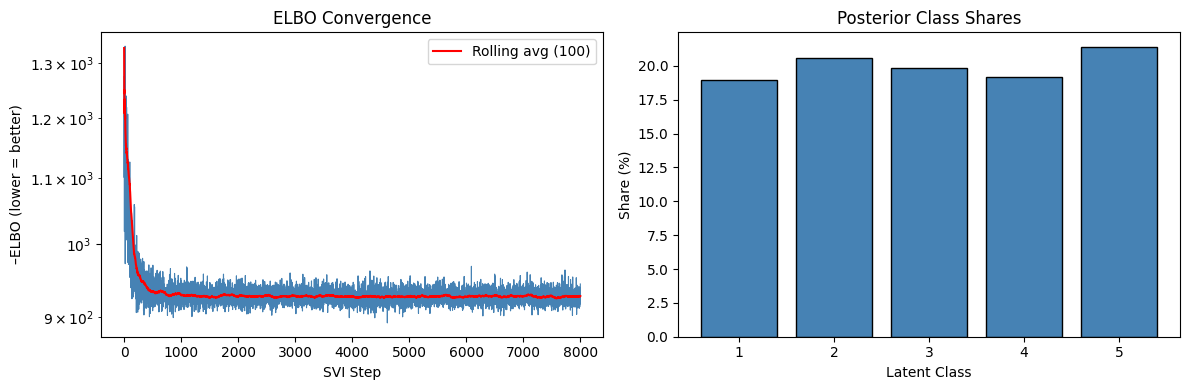


Figure saved to elbo_and_shares.png


In [13]:
# ── Posterior summaries ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

beta_mean  = pyro.param("beta_loc").detach()      # (K, 2)  -- param name now matches guide
asc_mean   = pyro.param("asc_loc").detach()       # (K, 2)
pi_conc    = pyro.param("pi_conc").detach()
class_shares = (pi_conc / pi_conc.sum())          # posterior mean of Dirichlet

# Class assignments: argmax of per-person logits
q_logits     = pyro.param("q_logits").detach()    # (n_persons, K)
q_probs_mean = torch.softmax(q_logits, dim=-1)    # per-person class probs

print("=" * 55)
print(f"{'Class':>6}  {'Share%':>8}  {'β_TT':>8}  {'β_Cost':>8}  {'VOT':>8}")
print("-" * 55)
for k in range(5):
    b_tt   = beta_mean[k, 0].item()
    b_cost = beta_mean[k, 1].item()
    vot    = (-b_tt / b_cost) if abs(b_cost) > 1e-6 else float('nan')
    print(f"  {k+1:>4}  {class_shares[k]*100:>7.1f}%  {b_tt:>8.3f}  {b_cost:>8.3f}  {vot:>8.3f}")
print("=" * 55)

# ── ELBO convergence plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses, color='steelblue', linewidth=0.8)
axes[0].set_xlabel('SVI Step')
axes[0].set_ylabel('–ELBO (lower = better)')
axes[0].set_title('ELBO Convergence')
axes[0].set_yscale('log')

# Smoothed (100-step rolling average)
smooth = pd.Series(losses).rolling(100, min_periods=1).mean()
axes[0].plot(smooth, color='red', linewidth=1.5, label='Rolling avg (100)')
axes[0].legend()

# Class shares bar chart
axes[1].bar(range(1, 6), class_shares.numpy() * 100, color='steelblue', edgecolor='k')
axes[1].set_xlabel('Latent Class')
axes[1].set_ylabel('Share (%)')
axes[1].set_title('Posterior Class Shares')
axes[1].set_xticks(range(1, 6))

plt.tight_layout()
plt.savefig('elbo_and_shares.png', dpi=120)
plt.show()
print('\nFigure saved to elbo_and_shares.png')
